# WNBA Player Viability main.py Evaluation Pipeline with Visualizations

In [1]:
import config
import numpy as np
import pandas as pd
import processing as pr
import analyze as az
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_squared_error
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

##### STEP 0. Load data, models, and params

In [2]:
#load cached data to df
finalWNBAFeatures = pd.read_parquet(config.dataDirCleaned / config.finalWNBAFeaturesFile)
finalNCAAFeatures = pd.read_parquet(config.dataDirCleaned / config.finalNCAAFeaturesFile)

#determine breakpoints for composite tiering. as set, there are 5 tiers of player but can be adjusted based on use case
tierQCut = [0,.0228,.1587,.8413,.9772, 1.00] #cuts based on standard normal distribution STDs. original arbitrary % based cuts - [0, 0.15, 0.40, 0.65, 0.90, 1.00]
tierLabels = [5,4,3,2,1] #must be list of int
targetNames = ['Not Viable','Roster Fillers','Bench Backups','Core Performers','Elite'] #corresponding string labels

#model tuning params
dt = DecisionTreeClassifier(random_state=14)
en = RandomForestClassifier(n_estimators=100, random_state=14)
rg = LinearRegression()
testSize = .2
randomState = 14

### Step 5. Create player classes and generate composite scores

In [3]:
#split data frame to get position specific dfs and fill NA stats with median of group
guards, forwards, centers = pr.fill_missing_values(finalWNBAFeatures,config.positionAbbvr)

#z-score normalization for composite features
guardsScaled,forwardsScaled,centersScaled = pr.normalize_features([guards,forwards,centers],config.featureStatsWNBA + ['total_games', 'total_minutes', 'total_seasons', 'game_availability_percentage'])

#### Composite Score Visualizations

Rookie Impact

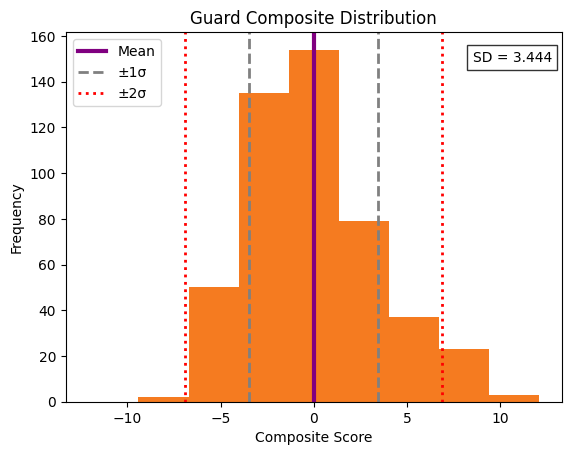

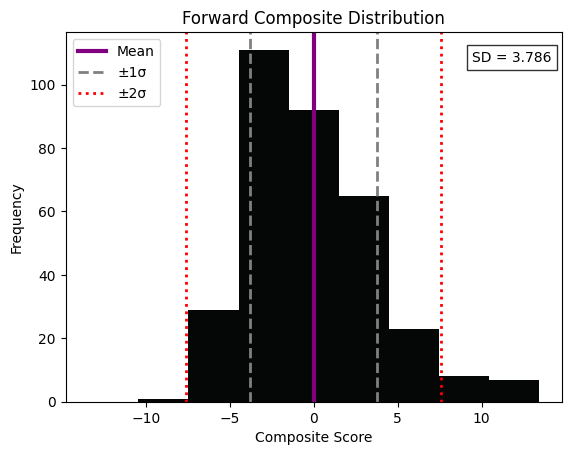

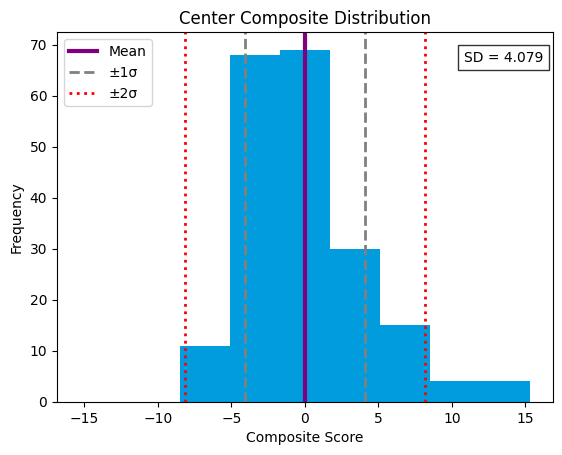

In [12]:
guardCompositeScore = pr.composite_score(guardsScaled,'guard')
forwardCompositeScore = az.composite_score(forwardsScaled, 'forward')
centerCompositeScore = az.composite_score(centersScaled, 'center')

for score,color,pos in zip([guardCompositeScore,forwardCompositeScore,centerCompositeScore],['#F57B20', '#050707', '#009CDE'],['Guard','Forward','Center']):
    max = np.abs(score).max()
    bins = np.linspace(-max,max,10)
    mean = score.mean()
    deviation = score.std()
    score.plot(kind='hist',bins=bins,title=f"{pos} Composite Distribution",xlabel='Composite Score',color=color)
    plt.axvline(mean, color='purple', linewidth=3, label='Mean')
    plt.axvline(mean - deviation, color='gray', linestyle='--', linewidth=2, label='±1σ')
    plt.axvline(mean + deviation, color='gray', linestyle='--', linewidth=2)
    plt.axvline(mean -2*deviation, color='red', linestyle=':', linewidth=2, label='±2σ')
    plt.axvline(mean +2*deviation, color='red', linestyle=':', linewidth=2)
    plt.text(
        0.98, 0.95,
        f'SD = {deviation:.3f}',
        transform=plt.gca().transAxes,
        ha='right',
        va='top',
        bbox=dict(facecolor='white', edgecolor='black', alpha=0.8)
    )
    plt.legend()
    plt.show()

5 Year Viability

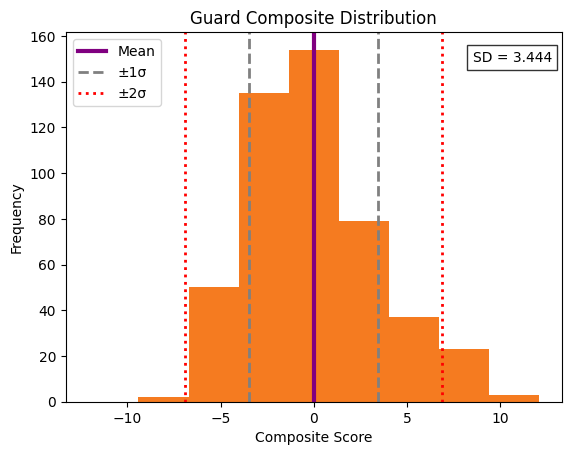

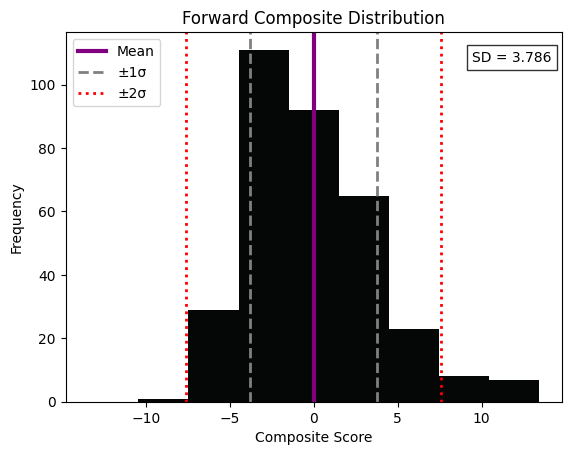

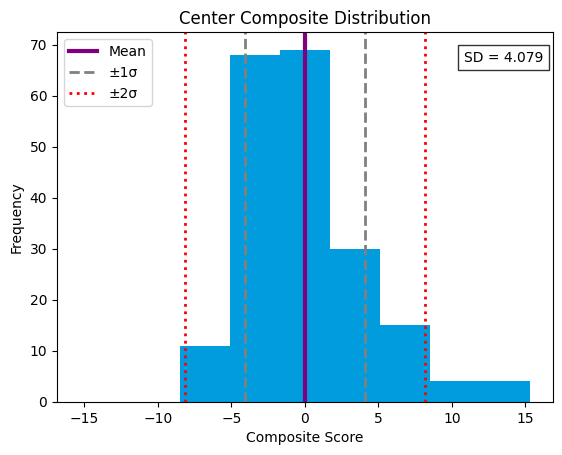

In [12]:
guardCompositeScore = pr.composite_score(guardsScaled,'guard')
forwardCompositeScore = az.composite_score(forwardsScaled, 'forward')
centerCompositeScore = az.composite_score(centersScaled, 'center')

for score,color,pos in zip([guardCompositeScore,forwardCompositeScore,centerCompositeScore],['#F57B20', '#050707', '#009CDE'],['Guard','Forward','Center']):
    max = np.abs(score).max()
    bins = np.linspace(-max,max,10)
    mean = score.mean()
    deviation = score.std()
    score.plot(kind='hist',bins=bins,title=f"{pos} Composite Distribution",xlabel='Composite Score',color=color)
    plt.axvline(mean, color='purple', linewidth=3, label='Mean')
    plt.axvline(mean - deviation, color='gray', linestyle='--', linewidth=2, label='±1σ')
    plt.axvline(mean + deviation, color='gray', linestyle='--', linewidth=2)
    plt.axvline(mean -2*deviation, color='red', linestyle=':', linewidth=2, label='±2σ')
    plt.axvline(mean +2*deviation, color='red', linestyle=':', linewidth=2)
    plt.text(
        0.98, 0.95,
        f'SD = {deviation:.3f}',
        transform=plt.gca().transAxes,
        ha='right',
        va='top',
        bbox=dict(facecolor='white', edgecolor='black', alpha=0.8)
    )
    plt.legend()
    plt.show()

Career Composite

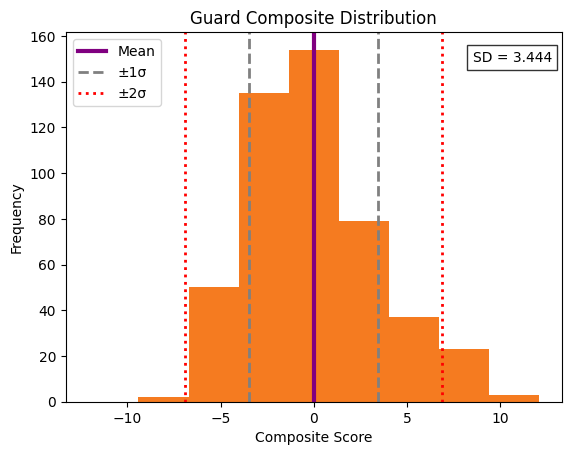

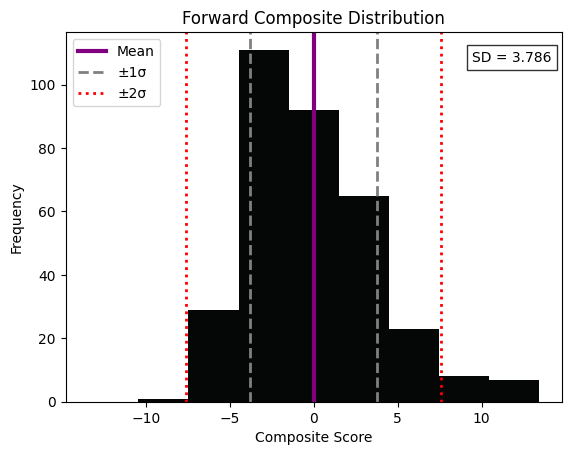

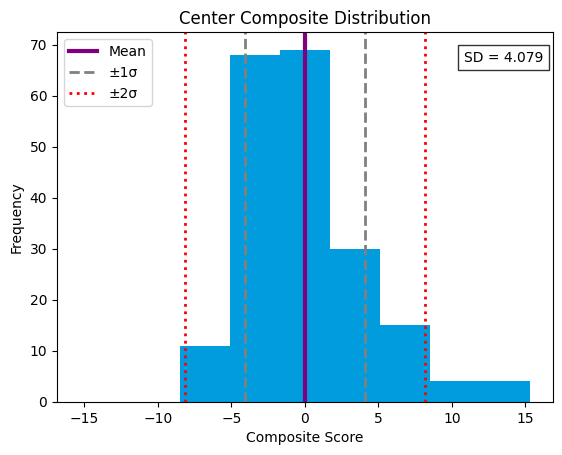

In [12]:
guardCompositeScore = pr.composite_score(guardsScaled,'guard')
forwardCompositeScore = az.composite_score(forwardsScaled, 'forward')
centerCompositeScore = az.composite_score(centersScaled, 'center')

for score,color,pos in zip([guardCompositeScore,forwardCompositeScore,centerCompositeScore],['#F57B20', '#050707', '#009CDE'],['Guard','Forward','Center']):
    max = np.abs(score).max()
    bins = np.linspace(-max,max,10)
    mean = score.mean()
    deviation = score.std()
    score.plot(kind='hist',bins=bins,title=f"{pos} Composite Distribution",xlabel='Composite Score',color=color)
    plt.axvline(mean, color='purple', linewidth=3, label='Mean')
    plt.axvline(mean - deviation, color='gray', linestyle='--', linewidth=2, label='±1σ')
    plt.axvline(mean + deviation, color='gray', linestyle='--', linewidth=2)
    plt.axvline(mean -2*deviation, color='red', linestyle=':', linewidth=2, label='±2σ')
    plt.axvline(mean +2*deviation, color='red', linestyle=':', linewidth=2)
    plt.text(
        0.98, 0.95,
        f'SD = {deviation:.3f}',
        transform=plt.gca().transAxes,
        ha='right',
        va='top',
        bbox=dict(facecolor='white', edgecolor='black', alpha=0.8)
    )
    plt.legend()
    plt.show()

Guard Standard Deviation: 3.05


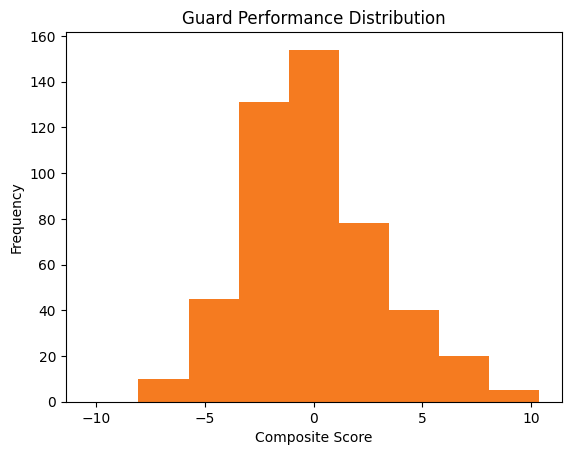

Forward Standard Deviation: 3.382


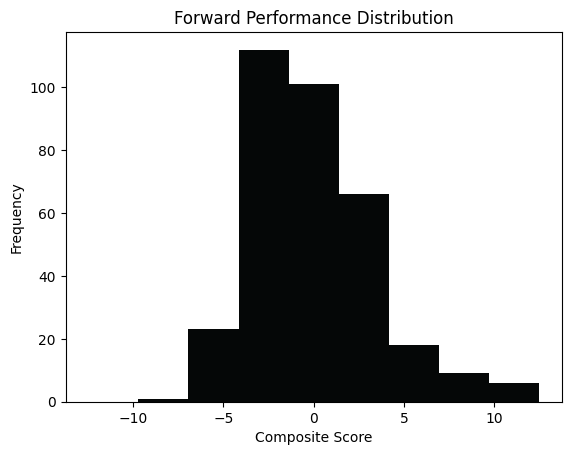

Center Standard Deviation: 3.667


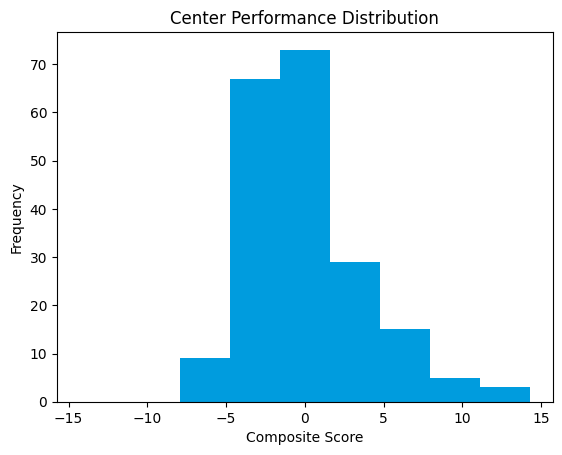

In [5]:
#generate composite score and standard deviation
guardCompositeScore = az.composite_score(guardsScaled,'guard')
print(f'Guard Standard Deviation: {round(guardCompositeScore.std(),3)}')

guardMax = np.abs(guardCompositeScore).max()
guardBins = np.linspace(-guardMax,guardMax,10)
guardCompositeScore.plot(kind='hist',bins=guardBins,title="Guard Performance Distribution",xlabel='Composite Score',color='#F57B20')
plt.show()

forwardCompositeScore = az.composite_score(forwardsScaled, 'forward')
print(f'Forward Standard Deviation: {round(forwardCompositeScore.std(),3)}')

forwardMax = np.abs(forwardCompositeScore).max()
forwardBins = np.linspace(-forwardMax, forwardMax, 10)
forwardCompositeScore.plot(kind='hist', bins=forwardBins, title="Forward Performance Distribution",xlabel='Composite Score', color='#050707')
plt.show()

centerCompositeScore = az.composite_score(centersScaled, 'center')
print(f'Center Standard Deviation: {round(centerCompositeScore.std(),3)}')

centerMax = np.abs(centerCompositeScore).max()
centerBins = np.linspace(-centerMax, centerMax, 10)
centerCompositeScore.plot(kind='hist', bins=centerBins, title="Center Performance Distribution",xlabel='Composite Score', color='#009CDE')
plt.show()

In [6]:
# determine tier cutoffs and reassign values back to original df
guardCompositeScore = pd.DataFrame(guardCompositeScore)
forwardCompositeScore = pd.DataFrame(forwardCompositeScore)
centerCompositeScore = pd.DataFrame(centerCompositeScore)
guardCompositeScore['tier'] = pd.qcut(guardCompositeScore[0],q=tierQCut,labels=tierLabels).astype(int)
forwardCompositeScore['tier'] = pd.qcut(forwardCompositeScore[0],q=tierQCut,labels=tierLabels).astype(int)
centerCompositeScore['tier'] = pd.qcut(centerCompositeScore[0],q=tierQCut,labels=tierLabels).astype(int)
finalWNBAFeatures = finalWNBAFeatures.join(centerCompositeScore['tier'])
finalWNBAFeatures['tier'] = finalWNBAFeatures['tier'].fillna(forwardCompositeScore['tier'])
finalWNBAFeatures['tier'] = finalWNBAFeatures['tier'].fillna(guardCompositeScore['tier'])

In [7]:
# STEP 6. RUN MODEL AND VISUALIZATIONS

In [8]:
#separate features by position and fill NA stats with median of group
modelGuards = finalNCAAFeatures[finalNCAAFeatures['athlete_position_abbreviation'] == 'G']
modelGuards = modelGuards.replace([np.inf, -np.inf], pd.NA).fillna(modelGuards[config.featureStatsNCAA].median())
modelForwards = finalNCAAFeatures[finalNCAAFeatures['athlete_position_abbreviation'] == 'F']
modelForwards = modelForwards.replace([np.inf, -np.inf], pd.NA).fillna(modelForwards[config.featureStatsNCAA].median())
modelCenters = finalNCAAFeatures[finalNCAAFeatures['athlete_position_abbreviation'] == 'C']
modelCenters = modelCenters.replace([np.inf, -np.inf], pd.NA).fillna(modelCenters[config.featureStatsNCAA].median())

# z-score normalization NCAA features
modelGuardsScaled = pd.DataFrame(scaler.fit_transform(modelGuards[(config.featureStatsNCAA + ['total_seasons', 'total_minutes', 'games_played'])]), columns=config.featureStatsNCAA + ['total_seasons', 'total_minutes', 'games_played'], index=guards.index)
modelForwardsScaled = pd.DataFrame(scaler.fit_transform(modelForwards[(config.featureStatsNCAA + ['total_seasons', 'total_minutes', 'games_played'])]), columns=config.featureStatsNCAA + ['total_seasons', 'total_minutes', 'games_played'], index=forwards.index)
modelCentersScaled = pd.DataFrame(scaler.fit_transform(modelCenters[(config.featureStatsNCAA + ['total_seasons', 'total_minutes', 'games_played'])]), columns=config.featureStatsNCAA + ['total_seasons', 'total_minutes', 'games_played'], index=centers.index)


Decision tree performance for Guards. Accuracy: 0.24742268041237114. Report:               precision    recall  f1-score   support

           1       0.25      0.14      0.18         7
           2       0.28      0.45      0.34        22
           3       0.29      0.11      0.16        36
           4       0.27      0.30      0.29        23
           5       0.12      0.22      0.15         9

    accuracy                           0.25        97
   macro avg       0.24      0.25      0.23        97
weighted avg       0.26      0.25      0.23        97
.


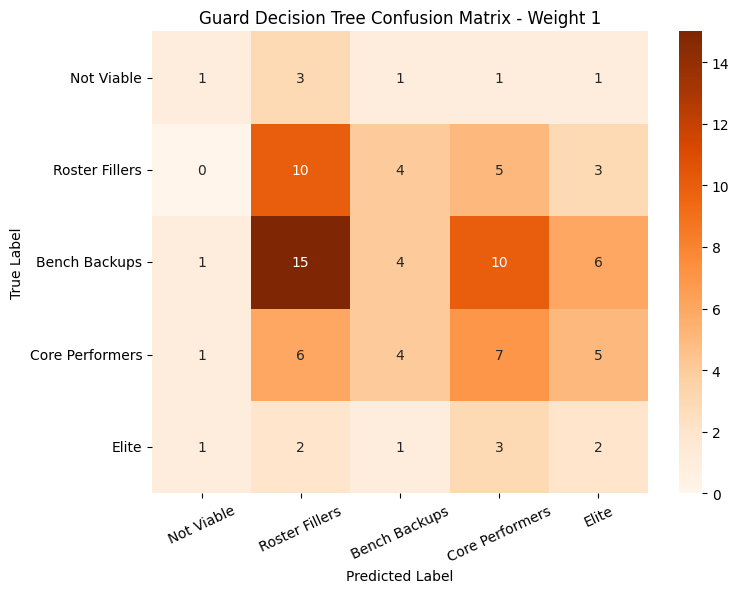

Ensemble performance for Guards. Accuracy: 0.28865979381443296. Report:               precision    recall  f1-score   support

           1       0.40      0.29      0.33         7
           2       0.35      0.36      0.36        22
           3       0.39      0.19      0.26        36
           4       0.26      0.43      0.32        23
           5       0.08      0.11      0.10         9

    accuracy                           0.29        97
   macro avg       0.30      0.28      0.27        97
weighted avg       0.32      0.29      0.29        97
.


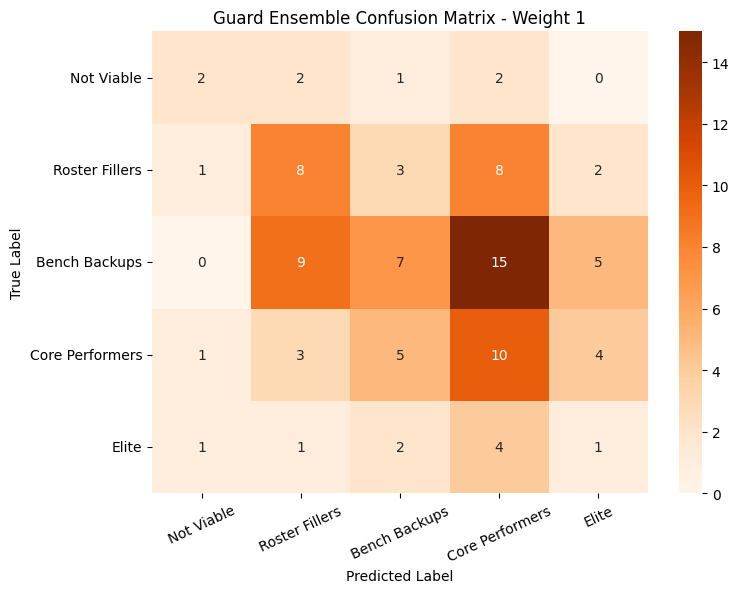

In [9]:
#Guards
gXTrain, gXTest, gYTrain, gYtest = train_test_split(modelGuardsScaled[config.featureStatsNCAA + ['total_seasons', 'total_minutes', 'games_played']], guardCompositeScore['tier'], test_size=testSize, random_state=randomState)
dt.fit(gXTrain,gYTrain)
gyPredDT = dt.predict(gXTest)
accuracyGuardDT = accuracy_score(gYtest, gyPredDT)
reportGuardDT = classification_report(gYtest, gyPredDT)
cmGuardDT = confusion_matrix(gYtest, gyPredDT)
print(f'Decision tree performance for Guards. Accuracy: {accuracyGuardDT}. Report: {reportGuardDT}.')

plt.figure(figsize=(8, 6))
sns.heatmap(cmGuardDT, annot=True, fmt='d', cmap='Oranges', xticklabels=targetNames, yticklabels=targetNames)
plt.title(f'Guard Decision Tree Confusion Matrix')
plt.xlabel('Predicted Label')
plt.xticks(rotation=25)
plt.ylabel('True Label')
plt.show()

en.fit(gXTrain, gYTrain)
gyPredEN = en.predict(gXTest)
accuracyGuardEN = accuracy_score(gYtest, gyPredEN)
reportGuardEN = classification_report(gYtest, gyPredEN)
cmGuardEN = confusion_matrix(gYtest, gyPredEN)
print(f'Ensemble performance for Guards. Accuracy: {accuracyGuardEN}. Report: {reportGuardEN}.')

plt.figure(figsize=(8, 6))
sns.heatmap(cmGuardEN, annot=True, fmt='d', cmap='Oranges',xticklabels=targetNames,yticklabels=targetNames)
plt.title(f'Guard Ensemble Confusion Matrix')
plt.xlabel('Predicted Label')
plt.xticks(rotation=25)
plt.ylabel('True Label')
plt.show()

Decision tree performance for Forwards. Accuracy: 0.2647058823529412. Report:               precision    recall  f1-score   support

           1       0.33      0.50      0.40         4
           2       0.22      0.25      0.24        16
           3       0.31      0.20      0.24        25
           4       0.25      0.36      0.29        14
           5       0.25      0.22      0.24         9

    accuracy                           0.26        68
   macro avg       0.27      0.31      0.28        68
weighted avg       0.27      0.26      0.26        68
.


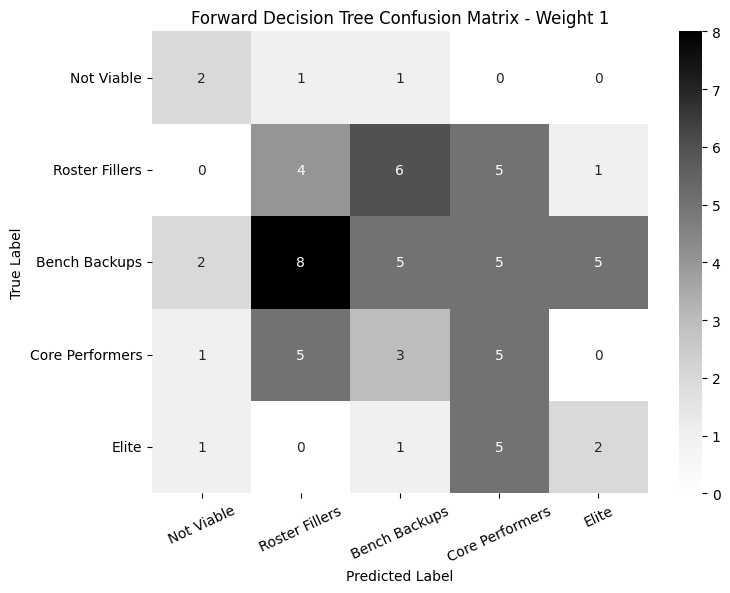

Ensemble performance for Forwards. Accuracy: 0.29411764705882354. Report:               precision    recall  f1-score   support

           1       0.33      0.25      0.29         4
           2       0.30      0.38      0.33        16
           3       0.32      0.24      0.27        25
           4       0.27      0.43      0.33        14
           5       0.25      0.11      0.15         9

    accuracy                           0.29        68
   macro avg       0.29      0.28      0.28        68
weighted avg       0.30      0.29      0.28        68
.


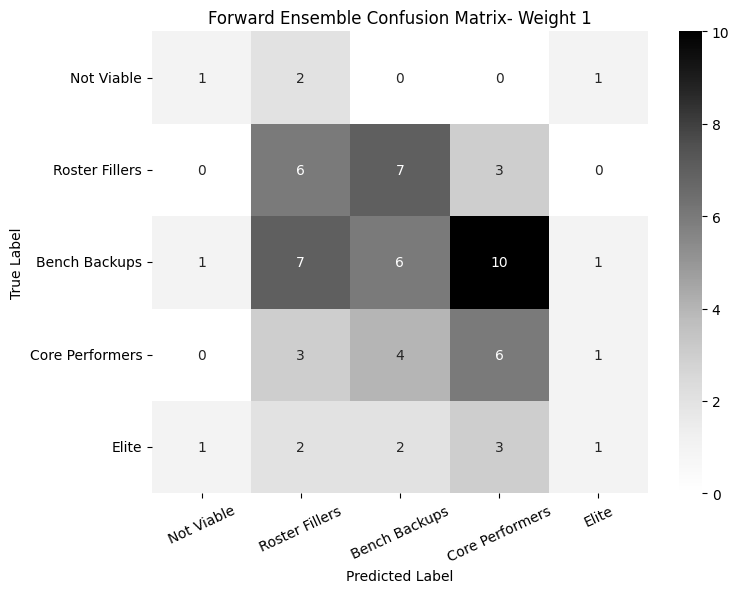

In [10]:
#Forwards
fXTrain, fXTest, fYTrain, fYtest = train_test_split(modelForwardsScaled[config.featureStatsNCAA + ['total_seasons', 'total_minutes', 'games_played']], forwardCompositeScore['tier'], test_size=testSize, random_state=randomState)
dt.fit(fXTrain, fYTrain)
fyPredDT = dt.predict(fXTest)
accuracyForwardDT = accuracy_score(fYtest, fyPredDT)
reportForwardDT = classification_report(fYtest, fyPredDT)
cmForwardDT = confusion_matrix(fYtest, fyPredDT)
print(f'Decision tree performance for Forwards. Accuracy: {accuracyForwardDT}. Report: {reportForwardDT}.')

plt.figure(figsize=(8, 6))
sns.heatmap(cmForwardDT, annot=True, fmt='d', cmap='Greys', xticklabels=targetNames, yticklabels=targetNames)
plt.title(f'Forward Decision Tree Confusion Matrix')
plt.xlabel('Predicted Label')
plt.xticks(rotation=25)
plt.ylabel('True Label')
plt.show()

en.fit(fXTrain, fYTrain)
fyPredEN = en.predict(fXTest)
accuracyForwardEN = accuracy_score(fYtest, fyPredEN)
reportForwardEN = classification_report(fYtest, fyPredEN)
cmForwardEN = confusion_matrix(fYtest, fyPredEN)
print(f'Ensemble performance for Forwards. Accuracy: {accuracyForwardEN}. Report: {reportForwardEN}.')

plt.figure(figsize=(8, 6))
sns.heatmap(cmForwardEN, annot=True, fmt='d', cmap='Greys', xticklabels=targetNames, yticklabels=targetNames)
plt.title(f'Forward Ensemble Confusion Matrix')
plt.xlabel('Predicted Label')
plt.xticks(rotation=25)
plt.ylabel('True Label')
plt.show()

Decision tree performance for Centers. Accuracy: 0.34146341463414637. Report:               precision    recall  f1-score   support

           1       0.00      0.00      0.00         2
           2       0.36      0.31      0.33        13
           3       0.25      0.33      0.29         9
           4       0.45      0.45      0.45        11
           5       0.40      0.33      0.36         6

    accuracy                           0.34        41
   macro avg       0.29      0.29      0.29        41
weighted avg       0.35      0.34      0.34        41
.


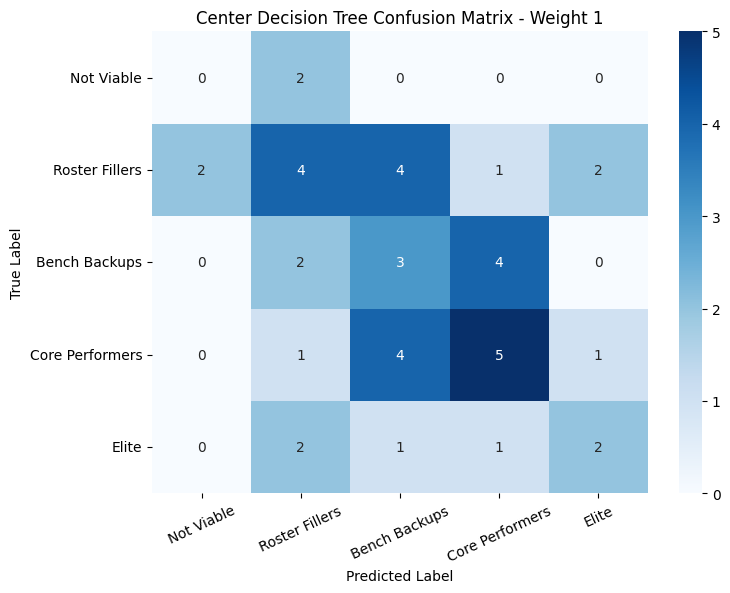

Ensemble performance for Centers. Accuracy: 0.4634146341463415. Report:               precision    recall  f1-score   support

           1       0.00      0.00      0.00         2
           2       0.46      0.46      0.46        13
           3       0.33      0.56      0.42         9
           4       0.58      0.64      0.61        11
           5       1.00      0.17      0.29         6

    accuracy                           0.46        41
   macro avg       0.48      0.36      0.35        41
weighted avg       0.52      0.46      0.44        41
.


/Users/kmonroygill/Documents/Conda Environments/spring2026/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/kmonroygill/Documents/Conda Environments/spring2026/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/kmonroygill/Documents/Conda Environments/spring2026/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parame

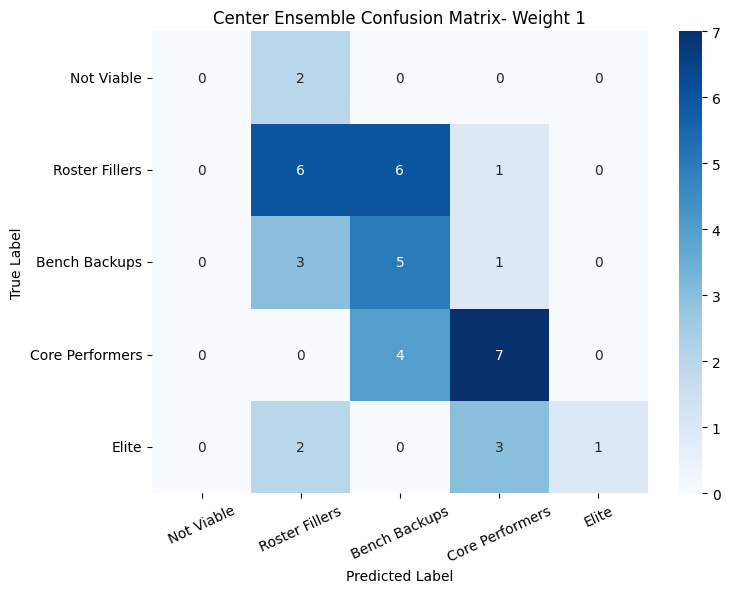

In [11]:
#Centers
cXTrain, cXTest, cYTrain, cYtest = train_test_split(modelCentersScaled[config.featureStatsNCAA + ['total_seasons', 'total_minutes', 'games_played']], centerCompositeScore['tier'], test_size=testSize, random_state=randomState)
dt.fit(cXTrain, cYTrain)
cyPredDT = dt.predict(cXTest)
accuracyCenterDT = accuracy_score(cYtest, cyPredDT)
reportCenterDT = classification_report(cYtest, cyPredDT)
cmCenterDT = confusion_matrix(cYtest, cyPredDT)
print(f'Decision tree performance for Centers. Accuracy: {accuracyCenterDT}. Report: {reportCenterDT}.')

plt.figure(figsize=(8, 6))
sns.heatmap(cmCenterDT, annot=True, fmt='d', cmap='Blues', xticklabels=targetNames, yticklabels=targetNames)
plt.title(f'Center Decision Tree Confusion Matrix')
plt.xlabel('Predicted Label')
plt.xticks(rotation=25)
plt.ylabel('True Label')
plt.show()

en.fit(cXTrain, cYTrain)
cyPredEN = en.predict(cXTest)
accuracyCenterEN = accuracy_score(cYtest, cyPredEN)
reportCenterEN = classification_report(cYtest, cyPredEN)
cmCenterEN = confusion_matrix(cYtest, cyPredEN)
print(f'Ensemble performance for Centers. Accuracy: {accuracyCenterEN}. Report: {reportCenterEN}.')

plt.figure(figsize=(8, 6))
sns.heatmap(cmCenterEN, annot=True, fmt='d', cmap='Blues', xticklabels=targetNames, yticklabels=targetNames)
plt.title(f'Center Ensemble Confusion Matrix')
plt.xlabel('Predicted Label')
plt.xticks(rotation=25)
plt.ylabel('True Label')
plt.show()

In [12]:
#draft regression
regData = finalWNBAFeatures[finalWNBAFeatures['draft_pick'] != 999]
regX = regData[['draft_pick']]
regY = regData['tier']

rg.fit(regX,regY)
yPred = rg.predict(regX)
r2 = rg.score(regX,regY)
mse = mean_squared_error(regY,yPred)
print(f'Regression performance for Draft Position and Tier. r2: {round(r2,3)}. Mean Square Error: {round(mse,3)}.')

Regression performance for Draft Position and Tier. r2: 0.242. Mean Square Error: 1.146.


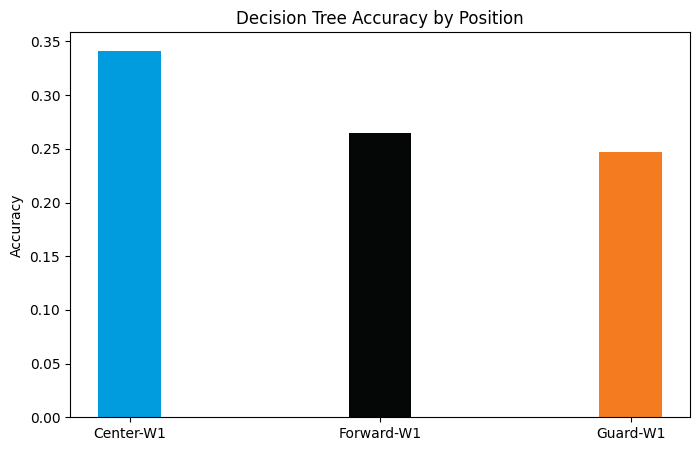

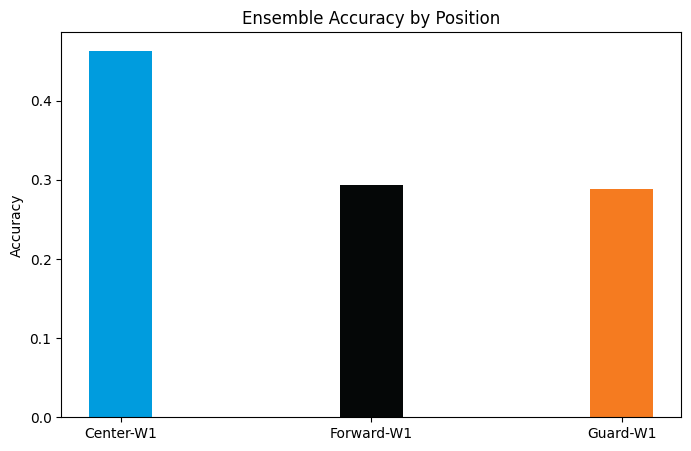

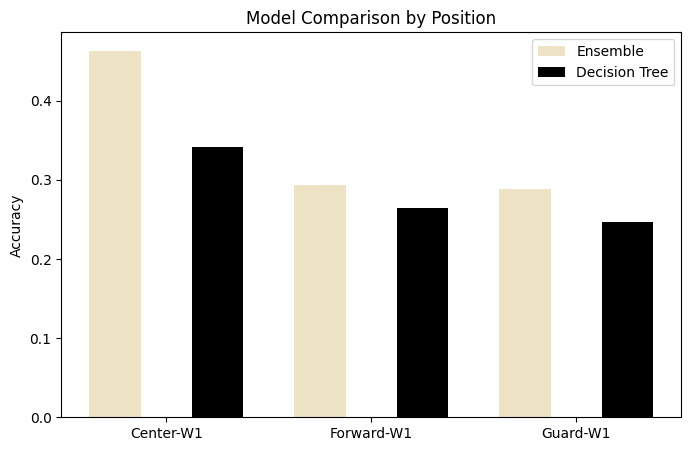

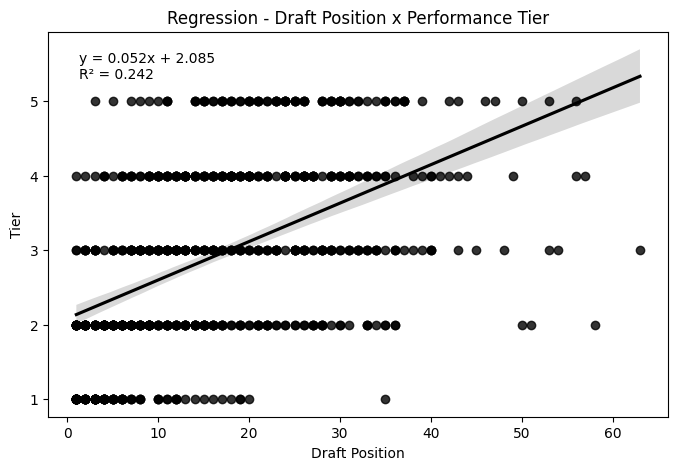

In [13]:
#visualizations
positions = ['Center','Forward','Guard']
dtViz = [accuracyCenterDT,accuracyForwardDT,accuracyGuardDT]
enViz = [accuracyCenterEN,accuracyForwardEN,accuracyGuardEN]
x = np.arange(len(positions))
width = .25

#Decision Tree bar
plt.figure(figsize=(8, 5))
plt.bar(x, dtViz, width,color=['#009CDE','#050707','#F57B20'])
plt.xticks(x, positions)
plt.ylabel('Accuracy')
plt.title('Decision Tree Accuracy by Position')
plt.show()

#Ensemble bar
plt.figure(figsize=(8, 5))
plt.bar(x, enViz, width,color=['#009CDE','#050707','#F57B20'])
plt.xticks(x, positions)
plt.ylabel('Accuracy')
plt.title('Ensemble Accuracy by Position')
plt.show()

#comparison bar
plt.figure(figsize=(8, 5))
plt.bar(x - width, enViz, width, label='Ensemble', color='#EFE3C6')
plt.bar(x + width, dtViz, width, label='Decision Tree', color='#000000')
plt.xticks(x, positions)
plt.ylabel('Accuracy')
plt.title('Model Comparison by Position')
plt.legend()
plt.show()

#regression plot
plt.figure(figsize=(8, 5))
sns.regplot(x="draft_pick", y="tier", data=regData,color='#000000')
slope = rg.coef_[0]
intercept = rg.intercept_
plt.text(0.05, 0.95,f'y = {slope:.3f}x + {intercept:.3f}\nR² = {r2:.3f}',transform=plt.gca().transAxes,verticalalignment='top')
plt.xlabel('Draft Position')
plt.ylabel('Tier')
plt.title('Regression - Draft Position x Performance Tier')
plt.show()